In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [2]:
# Parse the .sums file to extract metadata
def parse_sums_file(sums_file):
    file_info_list = []
    with open(sums_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                file_info_list.append(parts)
    return file_info_list

In [3]:
# Load image and label using the correct path
def load_image_and_label(file_info, base_dir, img_size=(96, 96)):
    image_path = file_info[1]
    image_path = image_path.replace("data/", "").replace("data\\", "")
    full_image_path = os.path.join(base_dir, image_path)

    # skips missing images if they exist in the .sums file but not in the directory
    if not os.path.exists(full_image_path):
        # silently skip missing images (faster for large dataset)
        return None, None

    # preprocess the image: resize, convert to grayscale, and normalize pixel values
    try:
        img = Image.open(full_image_path).convert("L")
        img = img.resize(img_size)

        # create img_array
        img_array = np.array(img, dtype=np.float32)
        
        # normalization
        img_array = img_array / 255.0

        label = os.path.basename(os.path.dirname(os.path.dirname(image_path)))

        return img_array, label

    except:
        return None, None

In [4]:
# Load dataset
sums_file = "AML-Cytomorphology_MLL_Helmholtz_v1.sums"
base_dir = "data"

file_info_list = parse_sums_file(sums_file)

# CNNs require lots of data, so took away previous 500 image limit 
# and implemented group by PATIENT instead of IMAGES to improve accuracy
patient_dict = defaultdict(list)

for file_info in file_info_list:
    path = file_info[1]

    # class label
    label = os.path.basename(os.path.dirname(os.path.dirname(path)))

    # patient id folder
    patient_id = os.path.basename(os.path.dirname(path))

    patient_dict[patient_id].append((file_info, label))

# FIX: split by patient instead of images
patients = list(patient_dict.keys())

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.25,
    random_state=42
)

train_files = []
test_files = []

for p in train_patients:
    train_files.extend(patient_dict[p])

for p in test_patients:
    test_files.extend(patient_dict[p])

# Limit dataset slightly for stability (important)
MAX_TRAIN = 15000
MAX_TEST = 4000

train_files = train_files[:MAX_TRAIN]
test_files = test_files[:MAX_TEST]


# Load images
train_images, train_labels = [], []
test_images, test_labels = [], []

for file_info, label in train_files:
    img, lab = load_image_and_label(file_info, base_dir)
    if img is not None:
        train_images.append(img)
        train_labels.append(lab)

for file_info, label in test_files:
    img, lab = load_image_and_label(file_info, base_dir)
    if img is not None:
        test_images.append(img)
        test_labels.append(lab)

print("Successfully loaded images for training:", len(train_images))
print("\nSuccessfully loaded images for testing:", len(test_images))

Successfully loaded images for training: 15000

Successfully loaded images for testing: 4000


In [5]:
# added label encoding for consistent ordering of data
unique_labels = sorted(list(set(train_labels)))
label_map = {label: idx for idx, label in enumerate(unique_labels)}

# train and test data
y_train = np.array([label_map[l] for l in train_labels], dtype=np.int32)
y_test = np.array([label_map[l] for l in test_labels], dtype=np.int32)

x_train = np.array(train_images, dtype=np.float32)
x_test = np.array(test_images, dtype=np.float32)

# reshaped rows and columns
img_rows, img_cols = x_train.shape[1], x_train.shape[2]

x_train = x_train.reshape(-1, img_rows, img_cols, 1)
x_test = x_test.reshape(-1, img_rows, img_cols, 1)

# Shuffle training data  
idx = np.random.permutation(len(x_train))
x_train = x_train[idx]
y_train = y_train[idx]

# Added class weights to balance data and prevent model from favoring majority AML classes
unique, counts = np.unique(y_train, return_counts=True)
class_weights = {i: len(y_train)/(len(unique)*c) for i, c in zip(unique, counts)}


In [6]:
# builds a CNN model with deeper convolutional layers, max pooling, regularization, and fully connected layers for classification
inpx = Input(shape=(img_rows, img_cols, 1))

# initial conv layer to detect low-level features (edges, textures)
conv_layer = Conv2D(32, (3,3), activation='relu', padding='same')(inpx)
# stabilizes training and improves convergence
conv_layer = BatchNormalization()(conv_layer)  
# reduced from (3,3) to (2,2) to keep more spatial info
pool_layer = MaxPooling2D((2,2))(conv_layer)   

# added a second convolutional layer to increase the model's capacity 
# and learn more complex features from the images, which can improve classification performance
second_conv_layer = Conv2D(64, (3,3), activation='relu', padding='same')(pool_layer)
# added batch normalization to help with accuracy
second_conv_layer = BatchNormalization()(second_conv_layer)
second_pool_layer = MaxPooling2D((2,2))(second_conv_layer)

#  added 3rd deeper convolutional layer to identify higher-level patterns in AML cells which morph
third_conv_layer = Conv2D(128, (3,3), activation='relu', padding='same')(second_pool_layer)
third_conv_layer = BatchNormalization()(third_conv_layer)
third_pool_layer = MaxPooling2D((2,2))(third_conv_layer)

# flattens to convert the 2D feature maps into a 1D vector
# uses GlobalAveragePooling2D() to reduce overfitting
flat_G = GlobalAveragePooling2D()(third_pool_layer)

# added first hidden layer with 128 neurons
# and 'relu' activation for model complexity
hid_layer = Dense(128, activation='relu')(flat_G)
# used Dropout to prevent overfitting of the medical data
hid_layer = Dropout(0.4)(hid_layer) 

# added a second hidden layer with 64 neurons 
# changed from 'tanh' activation to 'relu' for better gradient 
hid_layer2 = Dense(64, activation='relu')(hid_layer)

# output layer with softmax activation for multi-class classification, where the number of neurons corresponds to the number of unique labels
# we do this because AML has multiple subtypes, so we need to classify into more than two categories (unlike binary), and softmax allows us to get probabilities for each class
out_layer = Dense(len(unique_labels), activation='softmax')(hid_layer2)

model = Model([inpx], out_layer)

# compiles the model using the Adam optimizer for less cross-entropy loss and tracks accuracy as a metric 
# added a learning rate for more stable training
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# fits the model to training data for 10 epochs
# model will learn from data and adjust weights to minimize loss, with batch size of 128 for faster/efficient training
# validation used to help check performance on new, unseen data
model.fit(
    x_train,
    y_train,
    epochs=10, 
    batch_size=128,
    validation_data=(x_test, y_test),  
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 100s 810ms/step - accuracy: 0.3483 - loss: 1.4809 - val_accuracy: 0.2887 - val_loss: 1.6088
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 90s 759ms/step - accuracy: 0.4033 - loss: 1.3601 - val_accuracy: 0.2887 - val_loss: 2.0556
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 696ms/step - accuracy: 0.4296 - loss: 1.3092 - val_accuracy: 0.2887 - val_loss: 3.2995
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 86s 728ms/step - accuracy: 0.4495 - loss: 1.2668 - val_accuracy: 0.2898 - val_loss: 2.8928
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 92s 780ms/step - accuracy: 0.4717 - loss: 1.2376 - val_accuracy: 0.3540 - val_loss: 1.6818
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 89s 751ms/step - accuracy: 0.4856 - loss: 1.2102 - val_accuracy: 0.3968 - val_loss: 1.5211
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 90s 759ms/step - accuracy: 0.4988 - loss: 1.1862 - val_accuracy: 0.3425 - val_loss: 1.6211
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 84s 708ms/step - accuracy: 0.5073 - loss: 

In [8]:
# prints test accuracy of the model on unseen data to evaluate performance and generalization capability
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}%")


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.4338 - loss: 1.3210
Test accuracy: 43.38%


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


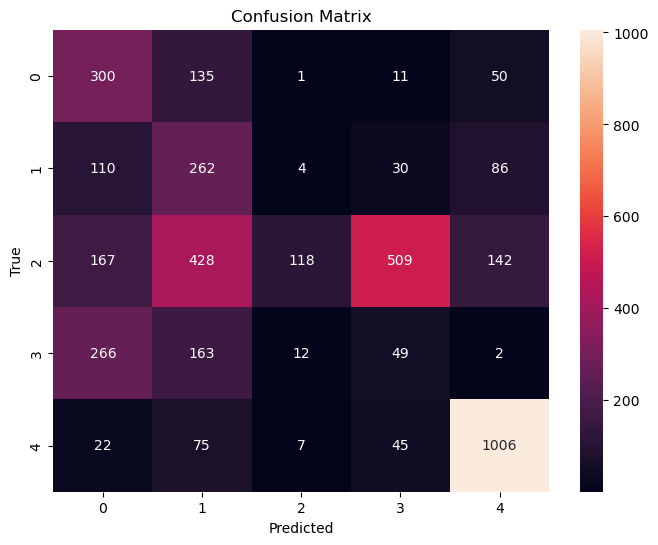

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# plots a confusion matrix for CNN model on AML
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [20]:
from sklearn.metrics import classification_report
# some more metrics like precision, recall, f1 score
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.35      0.60      0.44       497
           1       0.25      0.53      0.34       492
           2       0.83      0.09      0.16      1364
           3       0.08      0.10      0.09       492
           4       0.78      0.87      0.82      1155

    accuracy                           0.43      4000
   macro avg       0.46      0.44      0.37      4000
weighted avg       0.59      0.43      0.40      4000



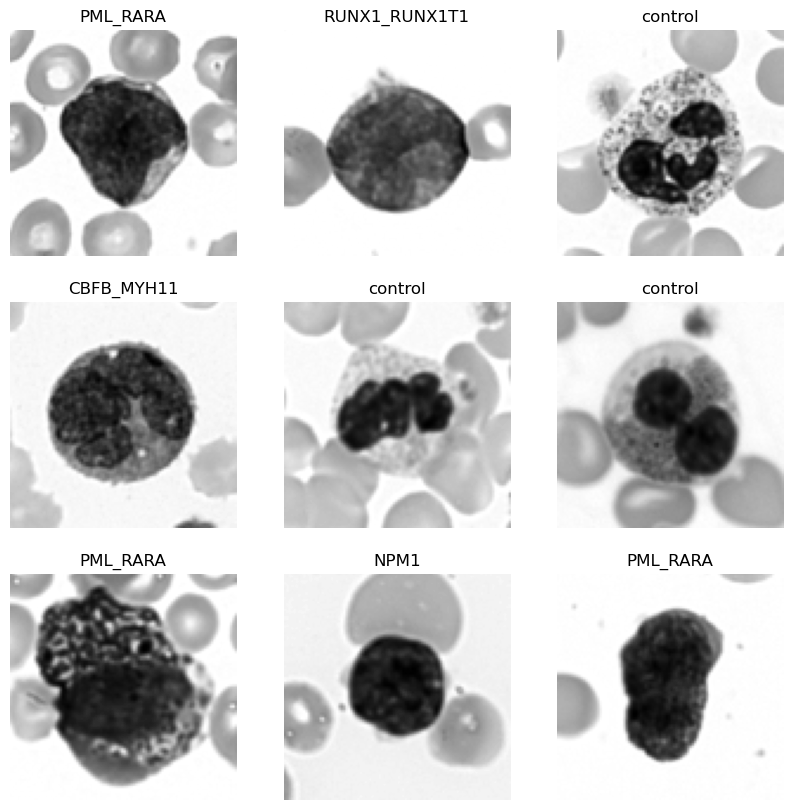

In [22]:
# visualizes the first 9 images from the test set along with their true labels 
# to qualitatively assess the model's performance and understand the data distribution

# inverse label mapping (numeric to class name)
idx_to_label = {v: k for k, v in label_map.items()}

# shuffle test set for visualization
idx = np.random.permutation(len(x_test))

plt.figure(figsize=(10,10))

# we can see if the model is correctly classifying different subtypes of AML by looking at the images and their corresponding labels, 
# which can help identify any patterns or misclassifications in the data
for i in range(9):
    img = x_test[idx[i]]
    label = y_test[idx[i]]

    plt.subplot(3,3,i+1)
    plt.imshow(img.reshape(img_rows, img_cols), cmap='gray')
    plt.title(idx_to_label[label])
    plt.axis('off')

plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


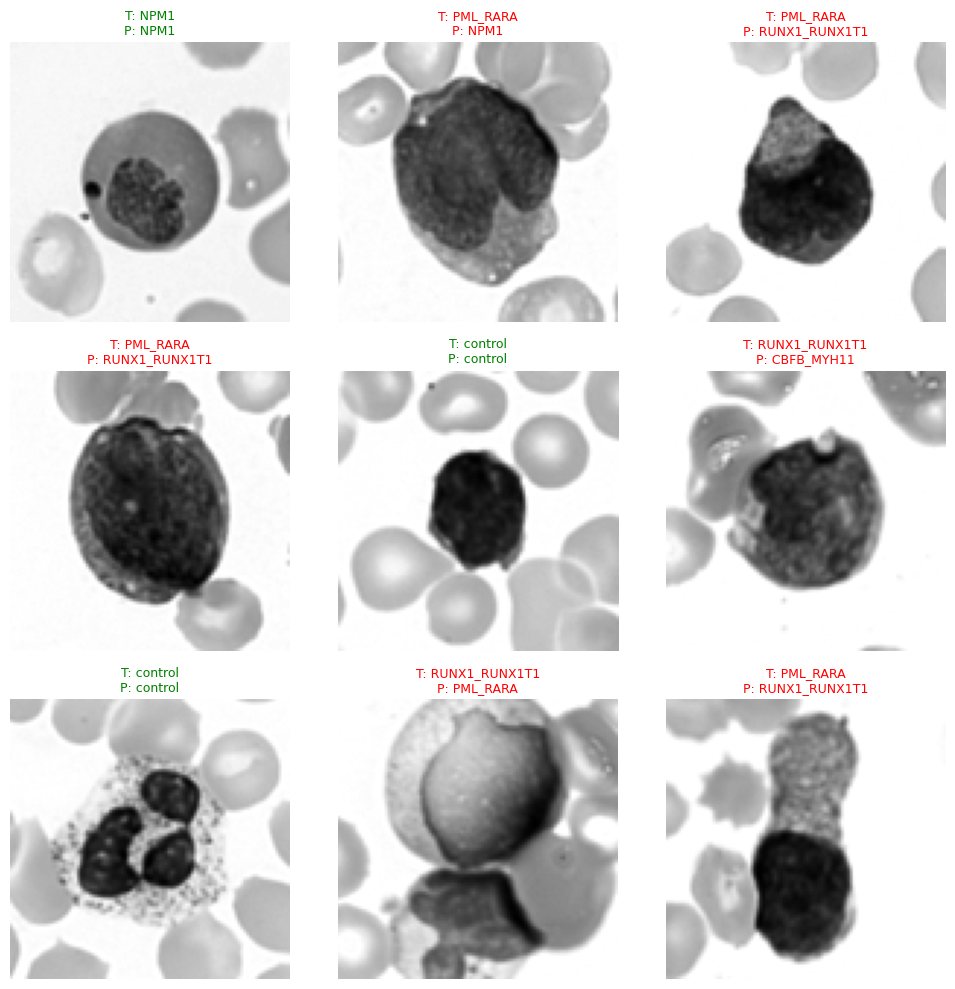

In [24]:
# get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# inverse label mapping
idx_to_label = {v: k for k, v in label_map.items()}

# random sample of 9 images
idx = np.random.permutation(len(x_test))

plt.figure(figsize=(10, 10))

for i in range(9):
    img = x_test[idx[i]]
    true_label = y_test[idx[i]]
    pred_label = y_pred_classes[idx[i]]

    true_name = idx_to_label[true_label]
    pred_name = idx_to_label[pred_label]

    correct = (true_label == pred_label)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.reshape(img_rows, img_cols), cmap='gray')
    plt.axis('off')

    color = "green" if correct else "red"

    plt.title(f"T: {true_name}\nP: {pred_name}", color=color, fontsize=9)

plt.tight_layout()
plt.show()